# Behavioural norming: stimulus specificity validation

This notebook validates the specificity structure of the specificity triad stimuli used in the MEG/EEG experiment. Participants completed a forced-choice task in which they selected the more specific or general (counterbalanced, blocked) of two items from a triad (e.g., *bird* vs. *nocturnal bird*).

**Pipeline:**
1. Load stimulus definitions and raw Gorilla data
2. Preprocess: clean columns, map trials to specificity contrasts, remove outliers
3. Compute sensitivity (d') and mean RT per subject per condition
4. Visualise and model results with linear mixed effects models
5. Robustness check: repeat analysis excluding 5 triads flagged by WordNet validation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import fig_constants  # just importing this applies all the rcParams globally
import fig_helpers as fh

## 1. Data loading and preparation

We load the stimulus triads and the raw behavioural data exported from Gorilla. The raw data file is the unmodified export from Gorilla experiment.

In [5]:
# Stimulus definitions — the final 100 triads used in the MEG experiment
material = pd.read_excel('stimuli_specificity_complete.xlsx')

material_low  = material[material.specificity == 'low'].word2.unique().tolist()
material_mid  = (material[material.specificity == 'mid'].word1 + ' ' +
                 material[material.specificity == 'mid'].word2).unique().tolist()
material_high = material[material.specificity == 'high'].word2.unique().tolist()

# Raw behavioural data exported from Gorilla (original filename: data_exp_135241-v8_task-f6xa.csv)
data_raw = pd.read_csv('data/norming_data_raw.csv', low_memory=False)

print(f'Loaded {len(material) // 3} stimulus triads.')
print(f'Loaded {data_raw["Participant External Session ID"].nunique()} participants.')

Loaded 100 stimulus triads.
Loaded 52 participants.


## 2. Preprocessing

We rename columns, identify the specificity contrast for each trial (e.g., low–mid, low–high, mid–high), and remove RT outliers (> 2.5 SD from the mean).

Contrasts are labelled by sorting the two levels alphabetically, which gives: `high-low`, `high-mid`, and `low-mid`.

In [7]:
# Map each word/phrase to its specificity level for fast trial labelling
word_to_level = {
    **{w: 'low'  for w in material_low},
    **{w: 'mid'  for w in material_mid},
    **{w: 'high' for w in material_high},
}

# Explicit contrast labels — sorted alphabetically to ensure consistency
CONTRAST_LABELS = {
    frozenset({'low',  'mid'})  : 'low-mid',
    frozenset({'low',  'high'}) : 'high-low',
    frozenset({'mid',  'high'}) : 'high-mid',
}

def identify_condition(row):
    l1 = word_to_level.get(row['option1'])
    l2 = word_to_level.get(row['option2'])
    if not l1 or not l2:
        return None
    return CONTRAST_LABELS.get(frozenset({l1, l2}))

# Rename columns, filter to experimental trials with a response
data = data_raw.rename(columns={
    'Participant External Session ID' : 'subject',
    'Display'                         : 'display',
    'Spreadsheet: option1'            : 'option1',
    'Spreadsheet: option2'            : 'option2',
    'Correct'                         : 'hit',
    'Reaction Time'                   : 'RT',
    'Response Type'                   : 'response_type',
})
data = data[(data.display == 'trial_experimental') & (data.response_type == 'response')]
data['condition'] = data.apply(identify_condition, axis=1)
data = data.dropna(subset=['condition'])

# Remove RT outliers > 2.5 SD from the mean
n_before = len(data)
data = data[np.abs(stats.zscore(data.RT)) < 2.5]
print(f'Removed {n_before - len(data)} RT outlier trials ({(n_before - len(data)) / n_before * 100:.1f}%).')
print(f'Remaining trials: {len(data)} across {data.subject.nunique()} participants.')

Removed 110 RT outlier trials (0.7%).
Remaining trials: 15438 across 52 participants.


## 3. Sensitivity (d') and accuracy

We compute d' per subject per condition. Because this is a 2AFC task, we calculate d' directly from proportion correct (pc): d' = √2 · z(pc).

To handle perfect scores (pc = 1), we apply the Hautus (1995) correction, adding 0.5 to the number of correct responses and 1 to the total trial count before computing the hit rate.

Participants with mean accuracy below 0.9 across conditions are excluded as low-quality responders.

In [11]:
def calculate_dprime(hits, total):
    """Compute d' for a 2AFC task using the Hautus (1995) correction.

    Adds 0.5 to hits and 1 to total to prevent infinite d' at ceiling.
    For 2AFC: d' = sqrt(2) * z(proportion correct).
    """
    pc = (hits + 0.5) / (total + 1)
    return np.sqrt(2) * stats.norm.ppf(pc)

def compute_summary_stats(df):
    """Aggregate hits, RT, d', and accuracy per subject per condition."""
    summary = (
        df.groupby(['subject', 'condition'])
        .agg(hits=('hit', 'sum'), total=('hit', 'count'), mean_RT=('RT', 'mean'))
        .reset_index()
    )
    summary['dprime']   = summary.apply(lambda r: calculate_dprime(r.hits, r.total), axis=1)
    summary['accuracy'] = summary.hits / summary.total
    summary['mean_RT']  = summary.mean_RT / 1000  # convert ms -> s
    return summary

summary_stats = compute_summary_stats(data)

# Exclude participants with mean accuracy < 0.9
overall_acc   = summary_stats.groupby('subject')['accuracy'].mean()
excluded_subs = overall_acc[overall_acc <= 0.9].index.tolist()
if excluded_subs:
    print(f'Excluding {len(excluded_subs)} low-accuracy participant(s): {excluded_subs}')
data_clean = summary_stats[~summary_stats.subject.isin(excluded_subs)]

print(f'Final participant count: {data_clean.subject.nunique()}')
print(data_clean.groupby('condition')[['mean_RT', 'dprime']].mean().round(3))

Excluding 22 low-accuracy participant(s): ['64be89e7a541a640dc942d68', '64be8bb77310c0ede34dde20', '64be8d49b914d7a4070ea73f', '64be8f9e6af66b9a8ea326e8', '64be92b21001a169775810ab', '64be92c1c4e9b34d14cfe418', '64be92ca13643f3275380072', '64be92cb3273e95f551b60e8', '64be92d22b012a0a4274e968', '64be92fa09bf47bbde61eba0', '64be93e0bad6ad19b149f25d', '64be94237951d2ff40de6461', '64be95ff306c3cd91de158dc', '64be99c2b96ead88ad4dddb4', '64be99c779f34e6885b8e89a', '64be99cfe9b25b7b0ba46cb3', '64be9a23984d54edb664ce8b', '64be9a5362b5b1af9b90096e', '64be9a8e0e83f405459418cb', '64be9b7e1e546518b6724d1b', '64bfa49bdbe959cbbc184a08', '64bfa5c5c371cdbfbc6bc332']
Final participant count: 30
           mean_RT  dprime
condition                 
high-low     1.634   2.662
high-mid     1.884   1.725
low-mid      1.478   2.652


## 4. Statistical modelling

We fit linear mixed effects models (LME) to test whether condition significantly
affects d' and RT, with subjects as a random effect. Follow-up pairwise comparisons
use Tukey HSD correction.

In [19]:
def run_lme(data_clean, outcome, label):
    """Fit a linear mixed effects model and run Tukey pairwise comparisons.

    Parameters
    ----------
    data_clean : DataFrame
        Subject-level summary with columns for outcome and 'condition'.
    outcome : str
        Column name of the dependent variable.
    label : str
        Label for printed output.

    Returns
    -------
    result : fitted MixedLM result
    tukey  : Tukey HSD result
    """
    print(f'--- LME: {label} ---')
    model  = smf.mixedlm(f'{outcome} ~ condition', data_clean, groups=data_clean['subject'])
    result = model.fit()
    print(result.summary())

    print(f'\n--- Pairwise comparisons (Tukey HSD): {label} ---')
    tukey = pairwise_tukeyhsd(endog=data_clean[outcome], groups=data_clean['condition'], alpha=0.05)
    print(tukey)
    return result, tukey

result_dprime, tukey_dprime = run_lme(data_clean, 'dprime',  "d' ~ condition")

--- LME: d' ~ condition ---
             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    dprime  
No. Observations:     90         Method:                REML    
No. Groups:           30         Scale:                 0.1431  
Min. group size:      3          Log-Likelihood:        -57.0720
Max. group size:      3          Converged:             Yes     
Mean group size:      3.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              2.662    0.084 31.581 0.000  2.497  2.827
condition[T.high-mid] -0.937    0.098 -9.592 0.000 -1.128 -0.745
condition[T.low-mid]  -0.009    0.098 -0.097 0.923 -0.201  0.182
Group Var              0.070    0.100                           


--- Pairwise comparisons (Tukey HSD): d' ~ condition ---
  Multiple Compar

In [20]:
result_rt,     tukey_rt     = run_lme(data_clean, 'mean_RT', 'RT ~ condition')

--- LME: RT ~ condition ---
             Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    mean_RT
No. Observations:      90         Method:                REML   
No. Groups:            30         Scale:                 0.0174 
Min. group size:       3          Log-Likelihood:        5.4754 
Max. group size:       3          Converged:             Yes    
Mean group size:       3.0                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              1.634    0.063 26.054 0.000  1.511  1.756
condition[T.high-mid]  0.250    0.034  7.348 0.000  0.184  0.317
condition[T.low-mid]  -0.156    0.034 -4.565 0.000 -0.222 -0.089
Group Var              0.101    0.259                           


--- Pairwise comparisons (Tukey HSD): RT ~ condition ---
  Multiple Compar

## 5. Visualisation

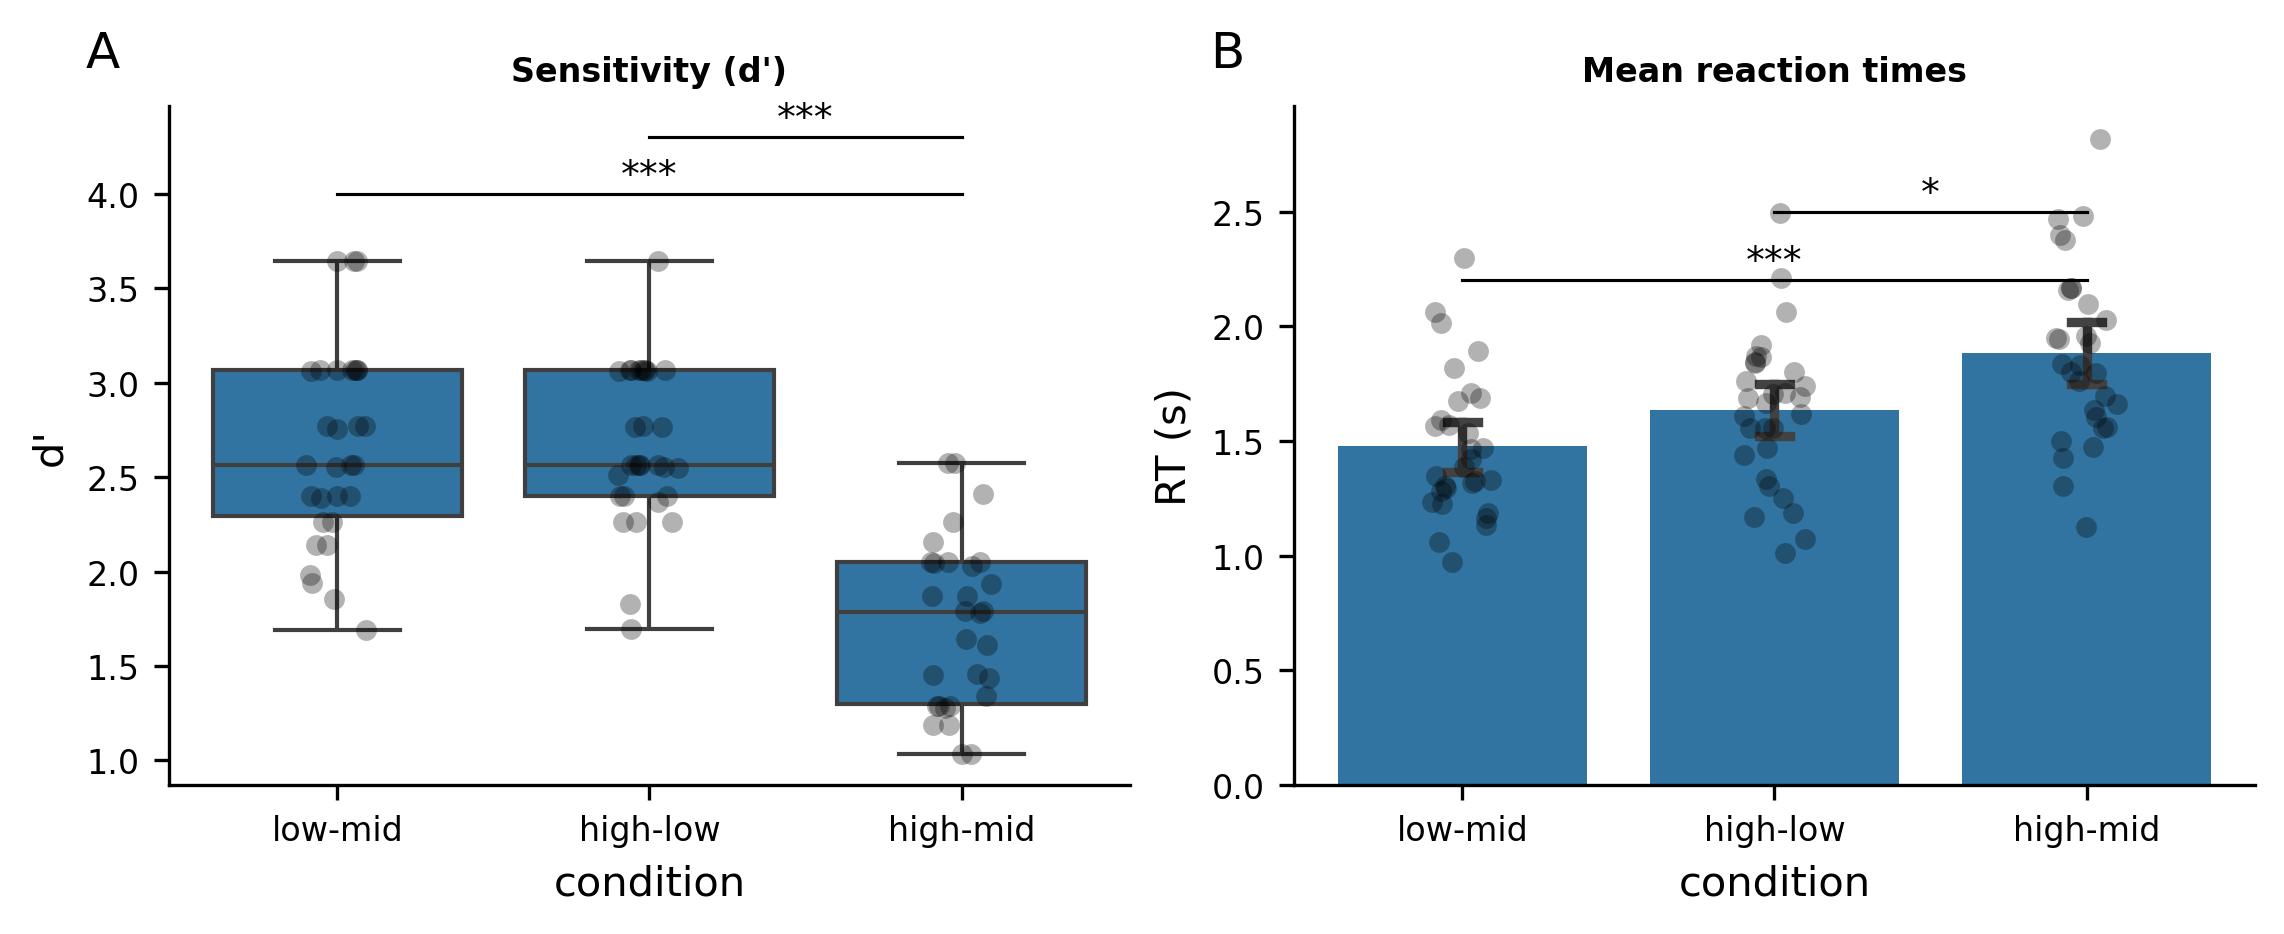

In [15]:
CONDITION_ORDER = ['low-mid', 'high-low', 'high-mid']

def plot_norming_results(data_clean, tukey_dprime, tukey_rt, suptitle=None):
    """Plot d' and RT distributions across specificity contrasts.

    Significance bars are drawn using p-values from the Tukey HSD results
    rather than hardcoded values.
    """
    fig, axes = plt.subplots(1, 2, figsize=(fig_constants.FIG_WIDTH, 3.),
                             dpi=300, constrained_layout=True)
    if suptitle:
        fig.suptitle(suptitle, fontsize=10, y=1.02)

    # Helper: extract Tukey p-value for a given pair of conditions
    def tukey_p(tukey, c1, c2):
        df = pd.DataFrame(data=tukey._results_table.data[1:],
                          columns=tukey._results_table.data[0])
        row = df[((df['group1'] == c1) & (df['group2'] == c2)) |
                 ((df['group1'] == c2) & (df['group2'] == c1))]
        return float(row['p-adj'].values[0]) if len(row) else None

    # d' panel
    sns.boxplot( data=data_clean, x='condition', y='dprime',   order=CONDITION_ORDER, ax=axes[0])
    sns.stripplot(data=data_clean, x='condition', y='dprime',  order=CONDITION_ORDER,
                  color='black', alpha=0.3, ax=axes[0])
    axes[0].set_title("Sensitivity (d')")
    axes[0].set_ylabel("d'")
    fh.add_significance_bar(axes[0], x1=0, x2=2, y_level=4.0,
                            p_value=tukey_p(tukey_dprime, 'low-mid', 'high-mid'))
    fh.add_significance_bar(axes[0], x1=1, x2=2, y_level=4.3,
                            p_value=tukey_p(tukey_dprime, 'high-low', 'high-mid'))

    # RT panel
    sns.barplot( data=data_clean, x='condition', y='mean_RT',  order=CONDITION_ORDER,
                 ax=axes[1], capsize=.1)
    sns.stripplot(data=data_clean, x='condition', y='mean_RT', order=CONDITION_ORDER,
                  color='black', alpha=0.3, ax=axes[1])
    axes[1].set_title('Mean reaction times')
    axes[1].set_ylabel('RT (s)')
    fh.add_significance_bar(axes[1], x1=0, x2=2, y_level=2.2,
                            p_value=tukey_p(tukey_rt, 'low-mid', 'high-mid'))
    fh.add_significance_bar(axes[1], x1=1, x2=2, y_level=2.5,
                            p_value=tukey_p(tukey_rt, 'high-low', 'high-mid'))

    fh.label_panels_mosaic(fig, {'A': axes[0], 'B': axes[1]})
    plt.show()

plot_norming_results(data_clean, tukey_dprime, tukey_rt)

## 6. Robustness check: excluding WordNet-flagged triads

Five triads were identified during computational validation (WordNet hypernym depth
analysis) as lacking a clear hyponymy relationship between the low- and
high-specificity nouns. We repeat the full analysis excluding these triads to confirm
that the main findings are not driven by these items.

Excluded pairs: cream/ointment, horse/zebra, river/stream, stick/icicle, snacks/crisps.

In [21]:
# Low/high noun pairs flagged as non-hyponymous by WordNet validation
EXCLUDED_WORDS = {'cream', 'ointment', 'horse', 'zebra', 'river',
                  'stream', 'stick', 'icicle', 'snacks', 'crisps'}

data_robust = data[
    ~data['option1'].isin(EXCLUDED_WORDS) &
    ~data['option2'].isin(EXCLUDED_WORDS)
].copy()

print(f'Trials before exclusion : {len(data)}')
print(f'Trials after exclusion  : {len(data_robust)}')
print(f'Trials removed          : {len(data) - len(data_robust)} '
      f'(~{(len(data) - len(data_robust)) / data.subject.nunique():.0f} per participant)')

Trials before exclusion : 15438
Trials after exclusion  : 14664
Trials removed          : 774 (~15 per participant)


Excluding 21 low-accuracy participant(s): ['64be89e7a541a640dc942d68', '64be8bb77310c0ede34dde20', '64be8d49b914d7a4070ea73f', '64be8f9e6af66b9a8ea326e8', '64be92b21001a169775810ab', '64be92c1c4e9b34d14cfe418', '64be92ca13643f3275380072', '64be92cb3273e95f551b60e8', '64be92d22b012a0a4274e968', '64be92fa09bf47bbde61eba0', '64be93e0bad6ad19b149f25d', '64be94237951d2ff40de6461', '64be95ff306c3cd91de158dc', '64be99c779f34e6885b8e89a', '64be99cfe9b25b7b0ba46cb3', '64be9a23984d54edb664ce8b', '64be9a5362b5b1af9b90096e', '64be9a8e0e83f405459418cb', '64be9b7e1e546518b6724d1b', '64bfa49bdbe959cbbc184a08', '64bfa5c5c371cdbfbc6bc332']
Final participant count: 31
           mean_RT  dprime
condition                 
high-low     1.603   2.738
high-mid     1.877   1.744
low-mid      1.487   2.644
--- LME: d' ~ condition (robust) ---
              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    dprime  
No. Observations:      93         Method:          

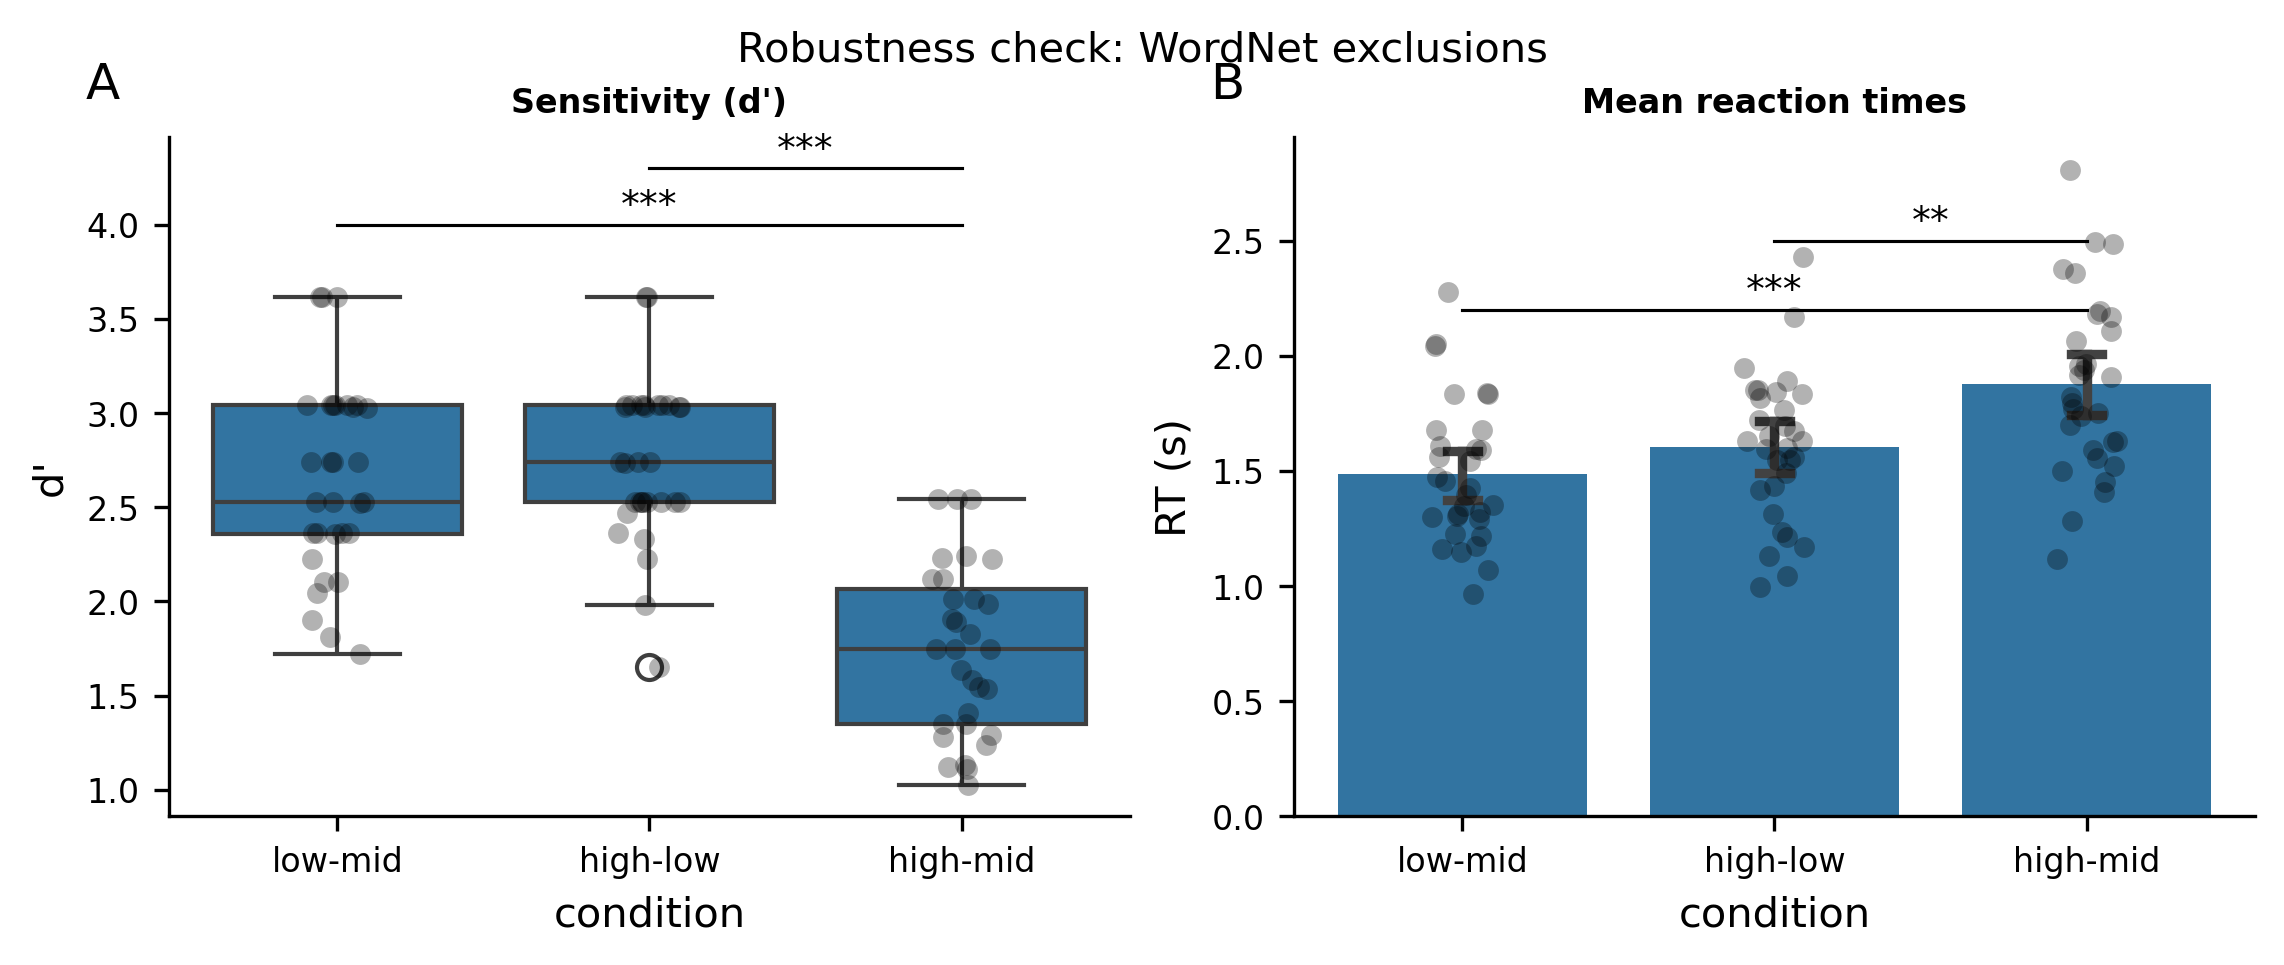

In [22]:
summary_robust   = compute_summary_stats(data_robust)
overall_acc_r    = summary_robust.groupby('subject')['accuracy'].mean()
excluded_subs_r  = overall_acc_r[overall_acc_r <= 0.9].index.tolist()
if excluded_subs_r:
    print(f'Excluding {len(excluded_subs_r)} low-accuracy participant(s): {excluded_subs_r}')
data_clean_robust = summary_robust[~summary_robust.subject.isin(excluded_subs_r)]

print(f'Final participant count: {data_clean_robust.subject.nunique()}')
print(data_clean_robust.groupby('condition')[['mean_RT', 'dprime']].mean().round(3))

result_dprime_r, tukey_dprime_r = run_lme(data_clean_robust, 'dprime',  "d' ~ condition (robust)")
result_rt_r,     tukey_rt_r     = run_lme(data_clean_robust, 'mean_RT', 'RT ~ condition (robust)')

plot_norming_results(data_clean_robust, tukey_dprime_r, tukey_rt_r,
                     suptitle='Robustness check: WordNet exclusions')

### Summary

Results replicate across both the full dataset and the robustness check:

- Participants showed robust sensitivity (d' > 1.7) across all three specificity contrasts.
- The mid–high contrast (*nocturnal bird* vs. *owl*) was significantly harder than both
  low–mid and low–high contrasts, reflected in lower d' and slower RTs.
- These findings hold after excluding the five WordNet-flagged triads, confirming
  that the specificity gradient is a reliable property of the stimulus set.